# 1. Imports

In [32]:
%load_ext autoreload

%reset -f
import sys
from os.path import dirname, join as pjoin
from os import listdir
sys.path.append('C:\\Users\\maryj\\OneDrive\\Desktop\\LAB') # set local directory
import numpy as np
import pickle
import random
#import xarray as xr
import pandas as pd
import warnings
from IPython import embed
import matplotlib.pyplot as plt
from collections import defaultdict

#import h5py
import scipy.io as sio
from scipy import stats
import statsmodels as sm # import statsmodels.api as 
from scipy.ndimage import uniform_filter1d
from scipy.signal import correlate

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 2. Setup

In [33]:
# load .pkl file for when access to server is not available/ to save time
im_beh_pkl = pd.read_pickle( "imaging_beh_sessions_dataframe.pkl")
df = pd.DataFrame(im_beh_pkl)
df.head()

,Date,Group,Mouse,a,R,LR_Prob,Reaction_Time
0,221118,RSCATN,JL025,"[1, 1, 1, 1, 2, 1, 1, 3, 2, 1, 3, 1, 1, 1, 1, ...","[0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...","[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, ...","[2.8923159999999997, 2.8556999999999997, 2.417..."
1,221122,RSCATN,JL025,"[1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, ...","[0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, ...","[2.495942, 2.971745, 2.942519, 2.820585, 2.385..."
2,221118,RSCATN,JL026,"[2, 1, 1, 1, 1, 1, 1, 2, 3, 2, 2, 2, 2, 4, 2, ...","[0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, ...","[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, ...","[3.1302950000000003, 3.152237, 3.305116, 3.044..."
3,221120,RSCATN,JL026,"[2, 3, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, ...","[1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, ...","[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, ...","[3.3334740000000003, 0.411344, 3.146925, 2.889..."
4,221201,RSCATN,JL026,"[2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, ...","[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...","[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, ...","[3.095911, 2.992583, 2.99742, 2.51994999999999..."


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Date           118 non-null    object
 1   Group          118 non-null    object
 2   Mouse          118 non-null    object
 3   a              118 non-null    object
 4   R              118 non-null    object
 5   LR_Prob        118 non-null    object
 6   Reaction_Time  118 non-null    object
dtypes: object(7)
memory usage: 6.6+ KB


## 2.1 Info about the data
- `Date`, `Group`: Information about when the experiments are performed, and by who.   
- `Mouse`: the specific mouse tested. We can see we are working with 2 mice.   
- `a`: The action the mice took. The experiments start with a ready period, and when the mice are given an audio queue, they are prompted to start acting.     
    - "1": The mouse went right
    - "2": The mouse went left  
    - "3": Miss. The mouse was given the audio cue, but did not do anything.   
    - "4": Alarm. The mouse started acting before given the audio cue.    
For actions 3 and 4, the rewards are intuitively set to 0, as no meaningful trajectories are performed.  
- `LR_prob`: The reward is randomly placed either on the left or the right given a probability, unique to each session. Therefore, the list for each session contain the same value. 
- `R`: The reward. 0 indicates no reward, 1 indicates yes. 
- `Reaction_Time`: the time the mice take to make another decision to move. 

## 2.2 Encoding data
We use dictionaries so it's easier to access for analysis; also because all trial sequences are not the same length. 

In [35]:
# Dictionary to store encoded session data, now including reward probability
encoded_sessions = {}

for idx, row in df.iterrows():
    # Encode choices: 1 → 0 (left), 2 → 1 (right), others → np.nan
    choices = np.array(row['a'])
    choices_encoded = np.where(choices == 1, 0,
                       np.where(choices == 2, 1, np.nan))
    
    # Rewards and reaction times as numeric arrays
    rewards = np.array(row['R'], dtype=int)
    reaction_times = np.array(row['Reaction_Time'], dtype=float)
    
    # Reward probability: take first element since same across session
    reward_prob = float(row['LR_Prob'][0])
    
    # Store in dictionary by session index
    encoded_sessions[idx] = {
        'Mouse': row['Mouse'],
        'Date': row['Date'],
        'choices': choices_encoded,
        'rewards': rewards,
        'reaction_times': reaction_times,
        'LR_Prob': reward_prob
    }

# Example: access session 0
print("Choices:", encoded_sessions[0]['choices'][:10])
print("Rewards:", encoded_sessions[0]['rewards'][:10])
print("Reward probability:", encoded_sessions[0]['LR_Prob'])

Choices: [ 0.  0.  0.  0.  1.  0.  0. nan  1.  0.]
Rewards: [0 0 0 0 1 0 0 0 1 0]
Reward probability: 0.1


# 3. Data visualization

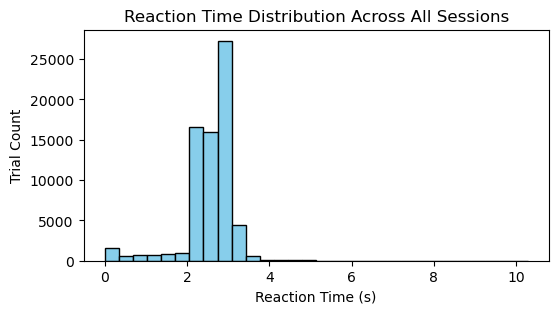

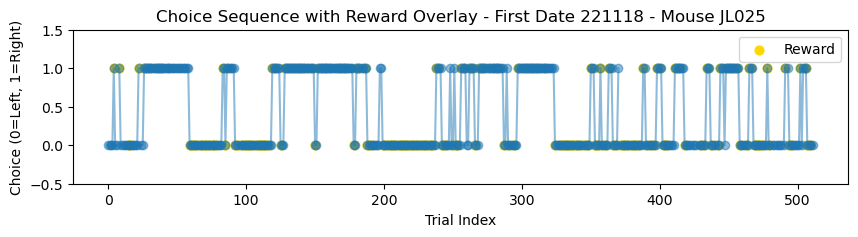

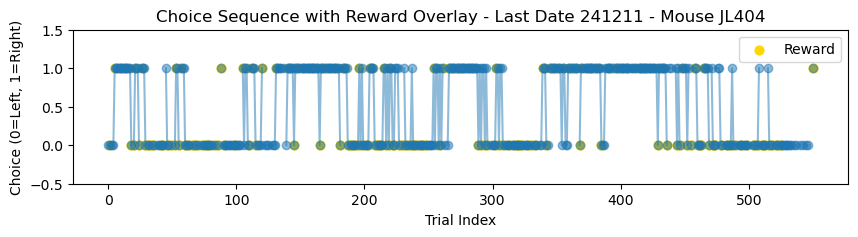

In [36]:
# ---------- Reaction Time Distribution (all sessions) ----------
all_rts = np.concatenate([encoded_sessions[idx]['reaction_times'] for idx in encoded_sessions])

plt.figure(figsize=(6,3))
plt.hist(all_rts, bins=30, color='skyblue', edgecolor='k')
plt.title('Reaction Time Distribution Across All Sessions')
plt.xlabel('Reaction Time (s)')
plt.ylabel('Trial Count')
plt.show()


# ---------- Choice Sequence with Reward Overlay (2 specific mice) ----------
# 1️⃣ Identify first and last training dates
all_dates = sorted({session['Date'] for session in encoded_sessions.values()})
first_date, last_date = all_dates[0], all_dates[-1]

# 2️⃣ Find first mouse for first date and first mouse for last date
first_mouse_session = None
last_mouse_session = None

for idx, session in encoded_sessions.items():
    if session['Date'] == first_date and first_mouse_session is None:
        first_mouse_session = session
    if session['Date'] == last_date and last_mouse_session is None:
        last_mouse_session = session

# 3️⃣ Plot for these 2 sessions
for session, label in zip([first_mouse_session, last_mouse_session], 
                          [f'First Date {first_date}', f'Last Date {last_date}']):
    choices = session['choices']
    rewards = session['rewards']
    
    plt.figure(figsize=(10,2))
    plt.plot(np.arange(len(choices)), choices, marker='o', linestyle='-', alpha=0.5)
    
    rewarded_trials = np.where(rewards==1)[0]
    plt.scatter(rewarded_trials, choices[rewarded_trials], color='gold', s=40, label='Reward')
    
    plt.title(f'Choice Sequence with Reward Overlay - {label} - Mouse {session["Mouse"]}')
    plt.xlabel('Trial Index')
    plt.ylabel('Choice (0=Left, 1=Right)')
    plt.ylim(-0.5, 1.5)
    plt.legend()
    plt.show()


In [37]:
df.head(1)['Reaction_Time']

0    [2.8923159999999997, 2.8556999999999997, 2.417...
Name: Reaction_Time, dtype: object

# 4. Auto correlation analysis
## 4.1 Auto-correlation of choices across sections

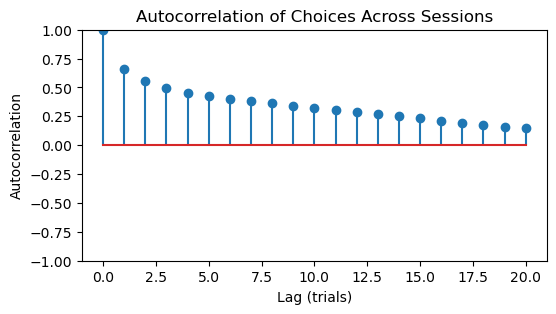

In [39]:

# ---------- Autocorrelation Across All Sessions ----------
# Build "sessions x trials" matrix
max_len = max(len(encoded_sessions[idx]['choices']) for idx in encoded_sessions)
choice_matrix = []

for idx in encoded_sessions:
    choices = encoded_sessions[idx]['choices']
    padded = np.full(max_len, np.nan)
    padded[:len(choices)] = choices
    choice_matrix.append(padded)

choice_matrix = np.array(choice_matrix)  # shape: sessions x max_len

# Compute autocorrelation
lags = 20
acorr = []

for lag in range(lags+1):
    corr_vals = []
    for row in choice_matrix:
        if lag == 0:
            corr_vals.append(1.0)
        else:
            valid_idx = ~np.isnan(row[lag:]) & ~np.isnan(row[:-lag])
            if np.sum(valid_idx) > 1:
                corr = np.corrcoef(row[:-lag][valid_idx], row[lag:][valid_idx])[0,1]
                corr_vals.append(corr)
    acorr.append(np.nanmean(corr_vals))

plt.figure(figsize=(6,3))
plt.stem(range(lags+1), acorr, )
plt.title('Autocorrelation of Choices Across Sessions')
plt.xlabel('Lag (trials)')
plt.ylabel('Autocorrelation')
plt.ylim(-1,1)
plt.show()

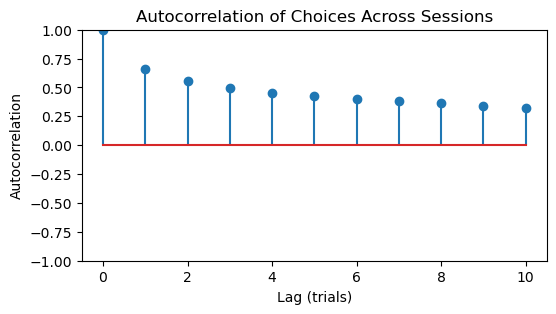

In [40]:
lags = 10
acorr = []

for lag in range(lags+1):
    corr_vals = []
    for row in choice_matrix:
        if lag == 0:
            corr_vals.append(1.0)
        else:
            valid_idx = ~np.isnan(row[lag:]) & ~np.isnan(row[:-lag])
            if np.sum(valid_idx) > 1:
                corr = np.corrcoef(row[:-lag][valid_idx], row[lag:][valid_idx])[0,1]
                corr_vals.append(corr)
    acorr.append(np.nanmean(corr_vals))

plt.figure(figsize=(6,3))
plt.stem(range(lags+1), acorr, )
plt.title('Autocorrelation of Choices Across Sessions')
plt.xlabel('Lag (trials)')
plt.ylabel('Autocorrelation')
plt.ylim(-1,1)
plt.show()

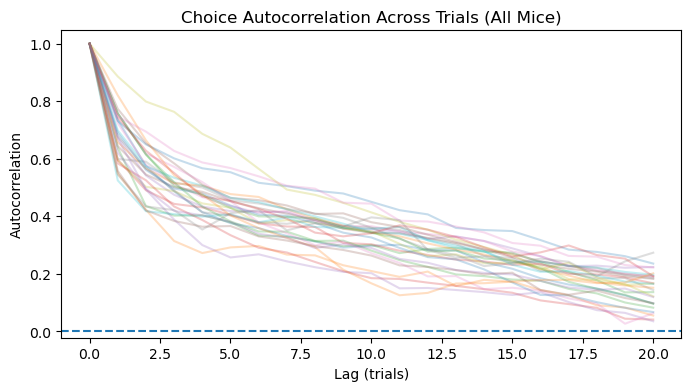

In [41]:
lags = 20

# Get all unique mice
mice = sorted({encoded_sessions[idx]['Mouse'] for idx in encoded_sessions})

plt.figure(figsize=(8,4))

for mouse in mice:

    # Collect sessions for this mouse
    mouse_sessions = [
        encoded_sessions[idx] for idx in encoded_sessions
        if encoded_sessions[idx]['Mouse'] == mouse
    ]

    # Find max trial length for this mouse
    max_len = max(len(s['choices']) for s in mouse_sessions)

    choice_matrix = []

    for s in mouse_sessions:
        choices = s['choices']
        padded = np.full(max_len, np.nan)
        padded[:len(choices)] = choices
        choice_matrix.append(padded)

    choice_matrix = np.array(choice_matrix)

    # Compute autocorrelation
    acorr = []

    for lag in range(lags+1):

        corr_vals = []

        for row in choice_matrix:

            if lag == 0:
                corr_vals.append(1.0)
                continue

            valid_idx = ~np.isnan(row[lag:]) & ~np.isnan(row[:-lag])

            if np.sum(valid_idx) > 1:

                x = row[:-lag][valid_idx]
                y = row[lag:][valid_idx]

                if np.std(x) > 0 and np.std(y) > 0:
                    corr = np.corrcoef(x, y)[0,1]
                    corr_vals.append(corr)

        acorr.append(np.nanmean(corr_vals))

    # Plot this mouse
    plt.plot(range(lags+1), acorr, alpha=0.25)

plt.title("Choice Autocorrelation Across Trials (All Mice)")
plt.xlabel("Lag (trials)")
plt.ylabel("Autocorrelation")
plt.axhline(0, linestyle="--")

plt.show()

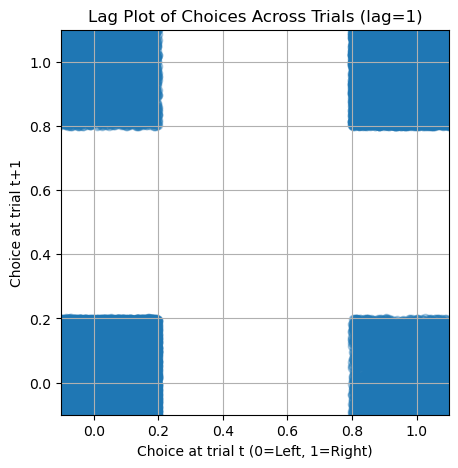

In [61]:
# ---------- Prepare choices across sessions ----------
all_choices = []
for s in encoded_sessions.values():
    choices = np.array(s['choices'], dtype=float)
    mask = ~np.isnan(choices)
    all_choices.extend(choices[mask])

all_choices = np.array(all_choices)

# ---------- Lag plot for lag=1 ----------
lag = 1
x_t = all_choices[:-lag]
x_t_lag = all_choices[lag:]

plt.figure(figsize=(5,5))
jitter = 0.2
plt.scatter(x_t + np.random.uniform(-jitter,jitter,len(x_t)),
            x_t_lag + np.random.uniform(-jitter,jitter,len(x_t_lag)),
            alpha=0.3)
plt.xlabel("Choice at trial t (0=Left, 1=Right)")
plt.ylabel(f"Choice at trial t+{lag}")
plt.title(f"Lag Plot of Choices Across Trials (lag={lag})")
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.grid(True)
plt.show()

## 4.2 Auto correlation of mice reaction time 
1. The two graphs below shows short term temporal dependence inside sessions.

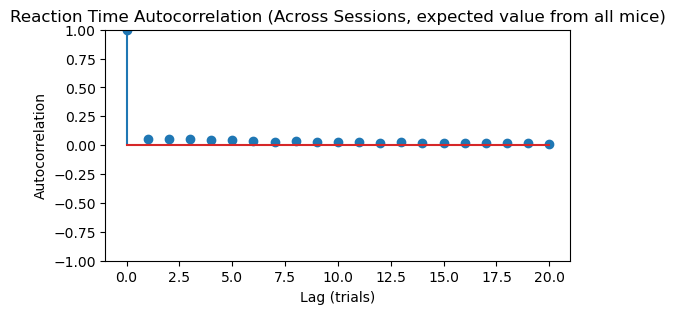

In [42]:
# ---------- Build sessions x trials matrix ----------
max_len = max(len(encoded_sessions[idx]['reaction_times']) for idx in encoded_sessions)

rt_matrix = []

for idx in encoded_sessions:
    rt = encoded_sessions[idx]['reaction_times']
    
    padded = np.full(max_len, np.nan)
    padded[:len(rt)] = rt
    
    rt_matrix.append(padded)

rt_matrix = np.array(rt_matrix)

# ---------- Compute autocorrelation ----------
lags = 20
rt_acorr = []

for lag in range(lags + 1):

    corr_vals = []

    for row in rt_matrix:

        if lag == 0:
            corr_vals.append(1.0)
            continue

        valid = ~np.isnan(row[:-lag]) & ~np.isnan(row[lag:])

        if np.sum(valid) > 2:

            x = row[:-lag][valid]
            y = row[lag:][valid]

            if np.std(x) > 0 and np.std(y) > 0:
                corr = np.corrcoef(x, y)[0,1]
                corr_vals.append(corr)

    rt_acorr.append(np.nanmean(corr_vals))

# ---------- Plot ----------
plt.figure(figsize=(6,3))
plt.stem(range(lags+1), rt_acorr)

plt.title("Reaction Time Autocorrelation (Across Sessions, expected value from all mice)")
plt.xlabel("Lag (trials)")
plt.ylabel("Autocorrelation")
plt.ylim(-1,1)

plt.show()

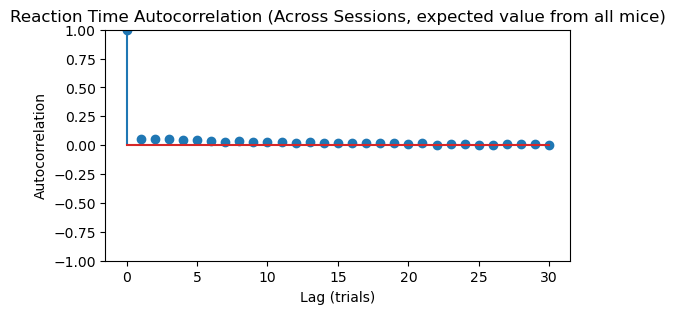

In [43]:
# ---------- Build sessions x trials matrix ----------
max_len = max(len(encoded_sessions[idx]['reaction_times']) for idx in encoded_sessions)

rt_matrix = []

for idx in encoded_sessions:
    rt = encoded_sessions[idx]['reaction_times']
    
    padded = np.full(max_len, np.nan)
    padded[:len(rt)] = rt
    
    rt_matrix.append(padded)

rt_matrix = np.array(rt_matrix)

# ---------- Compute autocorrelation ----------
lags = 30
rt_acorr = []

for lag in range(lags + 1):

    corr_vals = []

    for row in rt_matrix:

        if lag == 0:
            corr_vals.append(1.0)
            continue

        valid = ~np.isnan(row[:-lag]) & ~np.isnan(row[lag:])

        if np.sum(valid) > 2:

            x = row[:-lag][valid]
            y = row[lag:][valid]

            if np.std(x) > 0 and np.std(y) > 0:
                corr = np.corrcoef(x, y)[0,1]
                corr_vals.append(corr)

    rt_acorr.append(np.nanmean(corr_vals))

# ---------- Plot ----------
plt.figure(figsize=(6,3))
plt.stem(range(lags+1), rt_acorr)

plt.title("Reaction Time Autocorrelation (Across Sessions, expected value from all mice)")
plt.xlabel("Lag (trials)")
plt.ylabel("Autocorrelation")
plt.ylim(-1,1)

plt.show()

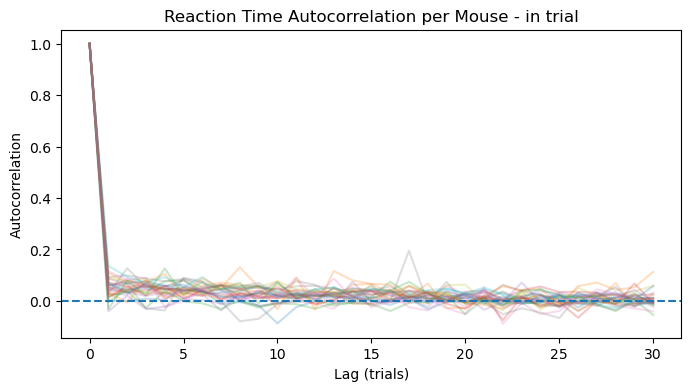

In [44]:
# ---------- Get list of mice ----------
mice = sorted({encoded_sessions[idx]['Mouse'] for idx in encoded_sessions})

plt.figure(figsize=(8,4))

for mouse in mice:

    mouse_sessions = [
        encoded_sessions[idx]
        for idx in encoded_sessions
        if encoded_sessions[idx]['Mouse'] == mouse
    ]

    corr_vals_mouse = []

    for lag in range(lags+1):

        session_corrs = []

        for s in mouse_sessions:

            rt = np.array(s['reaction_times'], dtype=float)

            if lag == 0:
                session_corrs.append(1.0)
                continue

            valid = ~np.isnan(rt[:-lag]) & ~np.isnan(rt[lag:])

            if np.sum(valid) > 2:

                x = rt[:-lag][valid]
                y = rt[lag:][valid]

                if np.std(x) > 0 and np.std(y) > 0:
                    corr = np.corrcoef(x, y)[0,1]
                    session_corrs.append(corr)

        if len(session_corrs) > 0:
            corr_vals_mouse.append(np.nanmean(session_corrs))
        else:
            corr_vals_mouse.append(np.nan)

    plt.plot(range(lags+1), corr_vals_mouse, alpha=0.25)

plt.title("Reaction Time Autocorrelation per Mouse - in trial")
plt.xlabel("Lag (trials)")
plt.ylabel("Autocorrelation")

plt.axhline(0, linestyle='--')

plt.show()

2. Exploration: expectation of reaction time across days 
This is not auto correlation, but still meaningful. 

# 5. Cross correlation

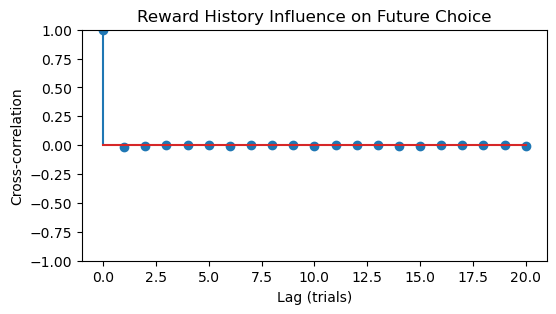

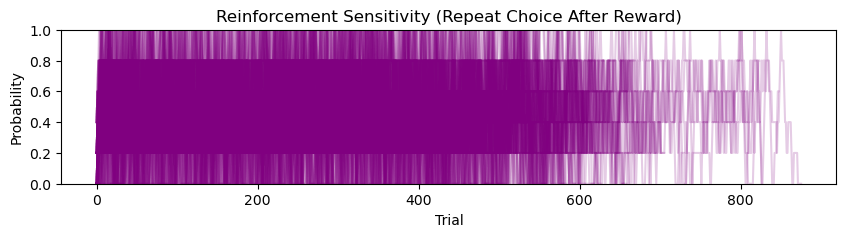

In [52]:
# ---------- Parameters ----------
max_lag = 20  # lag for cross-correlation in trials
window = 5    # rolling window for reinforcement sensitivity

# ---------- 1️⃣ Cross-Correlation: reward -> future choice ----------
plt.figure(figsize=(6,3))
all_xcorr = []

for s in encoded_sessions.values():
    choices = np.array(s['choices'], dtype=float)
    rewards = np.array(s['rewards'], dtype=float)
    
    valid = ~np.isnan(choices) & ~np.isnan(rewards)
    if np.sum(valid) < max_lag:
        continue

    choices = choices[valid]
    rewards = rewards[valid]

    x = rewards - np.mean(rewards)
    y = choices - np.mean(choices)
    
    corr = [np.corrcoef(x[:-lag], y[lag:])[0,1] if lag>0 else 1.0 for lag in range(max_lag+1)]
    all_xcorr.append(corr)

mean_xcorr = np.nanmean(all_xcorr, axis=0)
plt.stem(range(max_lag+1), mean_xcorr)
plt.xlabel("Lag (trials)")
plt.ylabel("Cross-correlation")
plt.title("Reward History Influence on Future Choice")
plt.ylim(-1,1)
plt.show()

# ---------- 5️⃣ Reinforcement sensitivity: repeat choice after reward ----------
plt.figure(figsize=(10,2))

for s in encoded_sessions.values():
    choices = np.array(s['choices'], dtype=float)
    rewards = np.array(s['rewards'], dtype=float)
    
    valid_mask = ~np.isnan(choices) & ~np.isnan(rewards)
    choices = choices[valid_mask]
    rewards = rewards[valid_mask]

    if len(choices) < window:
        continue

    repeat_after_reward = np.zeros(len(choices))
    repeat_after_reward[1:] = ((choices[1:] == choices[:-1]) & (rewards[:-1]==1)).astype(float)
    
    smoothed = uniform_filter1d(repeat_after_reward, size=window, mode='nearest')
    plt.plot(smoothed, alpha=0.2, color='purple')

plt.title("Reinforcement Sensitivity (Repeat Choice After Reward)")
plt.xlabel("Trial")
plt.ylabel("Probability")
plt.ylim(0,1)
plt.show()

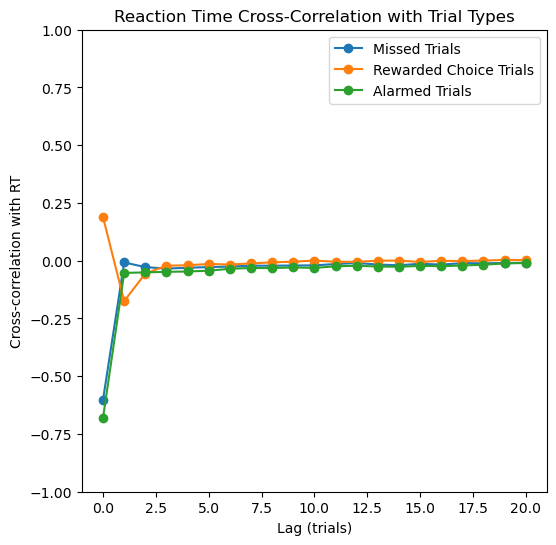

In [64]:
max_lag = 20  # number of trials for lag

def cross_corr_signal(trial_signal, rt_signal, max_lag):
    """Compute cross-correlation between binary trial signal and reaction times."""
    corr = []
    trial_signal = np.array(trial_signal, dtype=float)
    rt_signal = np.array(rt_signal, dtype=float)
    
    valid_mask = ~np.isnan(trial_signal) & ~np.isnan(rt_signal)
    trial_signal = trial_signal[valid_mask]
    rt_signal = rt_signal[valid_mask]
    
    for lag in range(max_lag+1):
        if lag == 0:
            corr.append(np.corrcoef(trial_signal, rt_signal)[0,1])
        else:
            if len(trial_signal) <= lag:
                corr.append(np.nan)
            else:
                corr.append(np.corrcoef(trial_signal[:-lag], rt_signal[lag:])[0,1])
    return corr

# ---------- Prepare all sessions ----------
missed_corrs = []
rewarded_corrs = []
alarmed_corrs = []

for s in encoded_sessions.values():
    choices = np.array(s['choices'], dtype=float)
    rts = np.array(s['reaction_times'], dtype=float)
    rewards = np.array(s['rewards'], dtype=float)
    
    valid_mask = ~np.isnan(rts)
    rts = rts[valid_mask]
    
    if len(rts) == 0:
        continue
    
    # Missed trials
    missed_signal = np.isnan(choices[valid_mask]).astype(float)
    missed_corrs.append(cross_corr_signal(missed_signal, rts, max_lag))
    
    # Rewarded choice trials
    rewarded_signal = ((rewards[valid_mask]==1) & (~np.isnan(choices[valid_mask]))).astype(float)
    rewarded_corrs.append(cross_corr_signal(rewarded_signal, rts, max_lag))
    
    # Alarmed trials (fastest 10% of RTs in session)
    threshold = np.percentile(rts, 10)
    alarmed_signal = (rts <= threshold).astype(float)
    alarmed_corrs.append(cross_corr_signal(alarmed_signal, rts, max_lag))

# ---------- Plot ----------
lags = np.arange(max_lag+1)

plt.figure(figsize=(6,6))
plt.plot(lags, np.nanmean(missed_corrs, axis=0), marker='o', label='Missed Trials')
plt.plot(lags, np.nanmean(rewarded_corrs, axis=0), marker='o', label='Rewarded Choice Trials')
plt.plot(lags, np.nanmean(alarmed_corrs, axis=0), marker='o', label='Alarmed Trials')
plt.xlabel("Lag (trials)")
plt.ylabel("Cross-correlation with RT")
plt.title("Reaction Time Cross-Correlation with Trial Types")
plt.legend()
plt.ylim(-1,1)
plt.show()

In [ ]:
# Left right bias 